
#  «Анализ данных об оптовых продажах аудиотехники»


1) orders (данные о заказах):  
- order_id — номер заказа  
- product_id — идентификатор товара  
- quantity — количество этого товара в заказе

2) order_status (данные о статусах заказов и клиентах):
- order_id — номер заказа  
- client_id — идентификатор клиента  
- status — статус заказа

3) products (данные о товарах):
- id — идентификатор товара  
- name — имя товара (сначала указан бренд, через запятую модель товара)  
- price — цена единицы товара, в долларах

Каждый заказ имеет статус или подтвержденного (`confirmed`), или отмененного (`canceled`). В одном заказе может быть несколько разных товаров. Если заказ был отменен, а потом создан такой же (тем же клиентом, с теми же товарами, у того же менеджера), в базе останется запись о двух заказах с разными номерами и статусами, поскольку система не позволяет создать заказ с тем же номером.

На схеме показано, как связаны таблицы между собой:

![](https://storage.yandexcloud.net/klms-public/production/learning-content/457/4167/37264/104636/497986/er_white.png)

Есть файл `usd_rate.txt` с курсом доллара США на каждый день анализируемого периода (данные в формате `дата,курс,валюта`). Он потребуется в середине проекта.

### Датасет с заказами по папкам

## Шаг 2

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Импортируйте библиотеки `pandas` и `os`.  
      
2) По аналогии с кодом, который вы использовали для сбора данных в 7-м уроке про грязные данные, сделайте следующее:  
a. создайте путь к папке `data`, используя ваш логин;  
b. соберите названия нужных вам файлов (`orders.csv`, `order_status.csv`, `products.csv`) в список `target_files`;  
c. создайте пустой список `data_files`, куда будете сохранять пути к файлам;  
d. с помощью функции `os.walk()` создайте генератор;  
e. с помощью цикла пройдитесь по генератору и, если название файла совпадает с нужным вам из списка `target_files`, путь к этому файлу добавьте в список `data_files`.
      
3) Используя пути к файлам из списка `data_files`, соберите полные датафреймы `df_orders`, `df_order_status` и `df_products`:  
a. создайте пустые списки `orders_df_list`, `order_status_df_list` и `products_df_list`, чтобы в них сложить данные для соответствующих датафреймов;  
b. с помощью цикла пройдитесь по путям в списке `data_files` и прочитайте датафрейм по этому пути. Добавьте датафрейм в тот или иной список в зависимости от того, название какого датасета содержит путь. Если в названии пути есть `orders.csv`, перед добавлением в список создайте колонки `manager` с именами менеджеров и `date` с датами. А если в названии пути есть `products.csv`, перед добавлением в список создайте колонку `category` с категориями товаров. Для создания колонок используйте подстроки из строки с путем.  
      
4) Каждый раз используя функцию `pd.concat` с параметром `ignore_index=True`, соберите данные в датафреймы: из списка `orders_df_list` в датафрейм `df_orders`, из списка `order_status_df_list` — в датафрейм `df_order_status`, а из списка `products_df_list` - в датафрейм `df_products`.

5) Отсортируйте каждый датафрейм с помощью метода `.sort_values()`, указав в нём необходимые колонки. Чтобы отсортировать датафрейм по нескольким колонкам, подайте на вход список с их названиями.
      
6) Проверьте размер каждого датафрейма и убедитесь, что:
- `df_orders` имеет размер (4603, 5)
- `df_order_status` — (346, 3)
- `df_products` — (1677, 4)
      
7) Сохраните каждый датафрейм в соответствующий csv файл, задав его название как строку и параметр `index=False`.
      
8) По одному скачайте получившиеся csv файлы из той же папки в JupyterHub, где находится ноутбук, в котором вы пишете этот код.

      
</p>
</details>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [ ]:
# df с заказами

In [4]:
df_orders = pd.DataFrame()
for path, dirs, files in os.walk('data'):
    for file in files:
        if file == 'orders.csv':
            file_path = os.path.join(path, file)
            data = pd.read_csv(file_path)
            data['manager'] = file_path.split('/')[-2]
            data['date'] = file_path.split('/')[2]
            df_orders = pd.concat([df_orders, data], ignore_index=True)
    

In [6]:
for path, dirs, files in os.walk('data'):
    print(path ,'\n', dirs ,'\n', files, '\n\n')

data 
 ['products', 'orders'] 
 ['.DS_Store'] 


data/products 
 ['Беспроводные наушники', 'Беспроводная акустика', 'Проводные наушники', 'Виниловый проигрыватель', 'Наушники с микрофоном', 'Ламповый усилитель', 'Сабвуфер', 'Домашний кинотеатр', 'Комплекты акустики', 'Музыкальный центр', 'Активные колонки', 'Интегральный усилитель', 'Динамический микрофон', 'Система караоке', 'Портативная акустика', 'Предусилитель', 'Умная колонка', 'Полочная акустика', 'Саундбар', 'AV-процессор', 'Центральный канал', 'Конденсаторный микрофон', 'AV-ресивер', 'Напольная акустика', 'Усилитель мощности', 'Настенная акустика'] 
 ['.DS_Store'] 


data/products/Беспроводные наушники 
 [] 
 ['products.csv'] 


data/products/Беспроводная акустика 
 [] 
 ['products.csv'] 


data/products/Проводные наушники 
 [] 
 ['products.csv'] 


data/products/Виниловый проигрыватель 
 [] 
 ['products.csv'] 


data/products/Наушники с микрофоном 
 [] 
 ['products.csv'] 


data/products/Ламповый усилитель 
 [] 
 ['p

In [ ]:
# df со статусами заказов

In [5]:
df_order_status = pd.DataFrame()
for path, dirs, files in os.walk('data'):
    for file in files:
        if file == 'order_status.csv':
            file_path = os.path.join(path, file)
            data = pd.read_csv(file_path)
            df_order_status = pd.concat([df_order_status, data], ignore_index=True)
    

In [6]:
df_orders.sort_values(['order_id', 'product_id'], inplace=True)

In [7]:
df_order_status.sort_values('order_id', inplace=True)

In [34]:
df_orders.head(3)

,order_id,product_id,quantity,manager,date
4291,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11
4288,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11
4299,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11


In [35]:
df_order_status.head(3)

,order_id,client_id,status
321,ABID-18767701,44,confirmed
95,ACXS-56511429,24,confirmed
124,AEDO-27030558,22,confirmed


In [ ]:
# df с информацией о продукте

In [8]:
df_products = pd.DataFrame()
for path, dirs, files in os.walk('data'):
    for file in files:
        if file == 'products.csv':
            file_path = os.path.join(path, file)
            data = pd.read_csv(file_path)
            data['category'] = file_path.split('/')[-2]
            df_products = pd.concat([df_products, data], ignore_index=True)

In [9]:
df_products.sort_values('id', inplace=True)

In [38]:
df_products.head()

,id,name,price,category
792,1,"AKG, D5",180.46,Динамический микрофон
793,2,"AKG, D40",85.80,Динамический микрофон
1308,3,"AKG, C414 XLII",935.11,Конденсаторный микрофон
1309,4,"AKG, C214",356.02,Конденсаторный микрофон
1310,5,"AKG, P120",86.13,Конденсаторный микрофон


In [49]:
# Проверка

In [10]:
df_orders.quantity.sum()

np.int64(85062)

In [11]:
df_order_status.client_id.sum()

np.int64(18347)

In [12]:
df_products.price.sum()

np.float64(839000.25)

### Общую динамика заказов и определим дни, которые выбиваются из общей картины

## Шаг 3

In [13]:
df_orders.date = pd.to_datetime(df_orders.date)

In [14]:
df_orders_by_day = df_orders.groupby('date') \
    .agg({'order_id': 'nunique'}) \
    .rename(columns={'order_id': 'orders'}) \
    .sort_values('orders', ascending=False) \
    .reset_index()

In [15]:
sns.set(
    font_scale=1.2,
    style="whitegrid",
    rc={'figure.figsize':(18, 6)}
        )

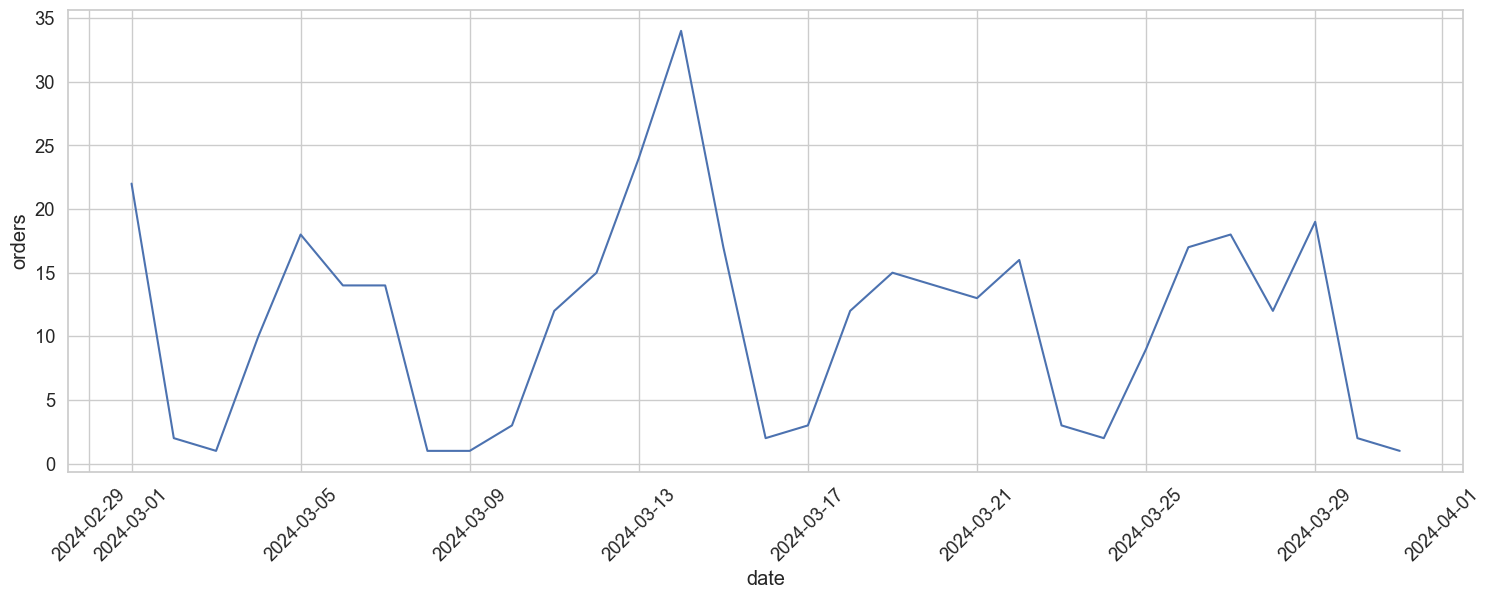

In [16]:
sns.lineplot(data=df_orders_by_day, x='date', y='orders')
plt.xticks(rotation=45)
plt.show()

In [17]:
import plotly.express as px

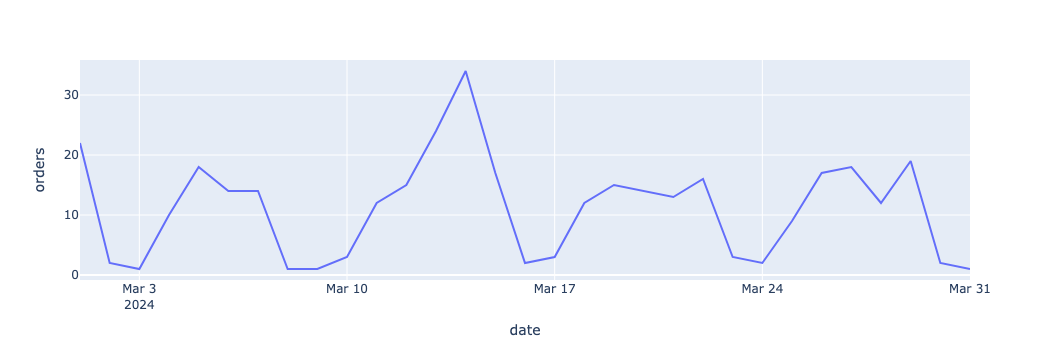

In [18]:
fig = px.line(df_orders_by_day.sort_values('date'), x='date', y='orders')
fig.show()

In [15]:
df_orders_by_day.sort_values('date').reset_index(drop=True) 
# Это праздничный день, в который было мало заказов

,date,orders
0,2024-03-01,22
1,2024-03-02,2
2,2024-03-03,1
3,2024-03-04,10
4,2024-03-05,18
5,2024-03-06,14
6,2024-03-07,14
7,2024-03-08,1
8,2024-03-09,1
9,2024-03-10,3


## Шаг 5

Возможно, в день с наибольшим числом заказов отдел маркетинга запустил какую-то акцию или менеджеры стали активнее предлагать компаниям оформить заказ? Нужно подробнее изучить этот день.

In [19]:
orders_status = df_orders.merge(df_order_status, how='inner', on='order_id')
orders_status.head(2)

,order_id,product_id,quantity,manager,date,client_id,status
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed


In [20]:
orders_status.client_id.sum()

np.int64(251232)

In [21]:
orders_status.to_csv('orders_status.csv', index=False)

Количество и соотношение подтвержденных и отмененных заказов.

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Чтобы оставить в данных только информацию о том, был заказ подтвержден или отменен, выберите из датафрейма `orders_status` колонки с номером заказа и статусом, а затем удалите дубликаты (НЕ сохраняйте результат в тот же датафрейм, потому что `orders_status` в полном виде понадобится для решения следующих заданий).

2) Посчитайте частоту, с которой встречается каждый из статусов в оставшихся данных.

3) Посчитайте долю каждого из статусов. Значения округлите до 2 знаков после точки.

      
</p>
</details>

In [22]:
orders_status[['order_id', 'status']].drop_duplicates().value_counts('status', normalize=True).round(2)

status
confirmed    0.89
canceled     0.11
Name: proportion, dtype: float64

**Количество подтвержденных и отмененных заказов на каждую дату.**  

In [23]:
orders_type_by_date = orders_status.groupby(['date', 'status'], as_index=False) \
    .agg({'order_id': 'nunique'}) \
    .pivot(index='date', columns='status', values='order_id') \
    .fillna(0) \
    .sort_values('confirmed')


In [24]:
orders_type_by_date = orders_type_by_date \
    .assign(total_orders = orders_type_by_date.canceled + orders_type_by_date.confirmed)
orders_type_by_date.reset_index(inplace=True)

In [22]:
orders_type_by_date.head()

status,date,canceled,confirmed,total_orders
0,2024-03-09,1.0,0.0,1.0
1,2024-03-31,0.0,1.0,1.0
2,2024-03-03,0.0,1.0,1.0
3,2024-03-08,0.0,1.0,1.0
4,2024-03-24,0.0,2.0,2.0


In [25]:
total_orders_by_status = orders_status.groupby(['date', 'status'], as_index=False) \
    .agg({'order_id': 'nunique'}) \
    .fillna(0)
total_orders_by_status

,date,status,order_id
0,2024-03-01,canceled,2
1,2024-03-01,confirmed,20
2,2024-03-02,confirmed,2
3,2024-03-03,confirmed,1
4,2024-03-04,confirmed,10
5,2024-03-05,confirmed,18
6,2024-03-06,canceled,1
7,2024-03-06,confirmed,13
8,2024-03-07,canceled,1
9,2024-03-07,confirmed,13


<Axes: xlabel='date', ylabel='order_id'>

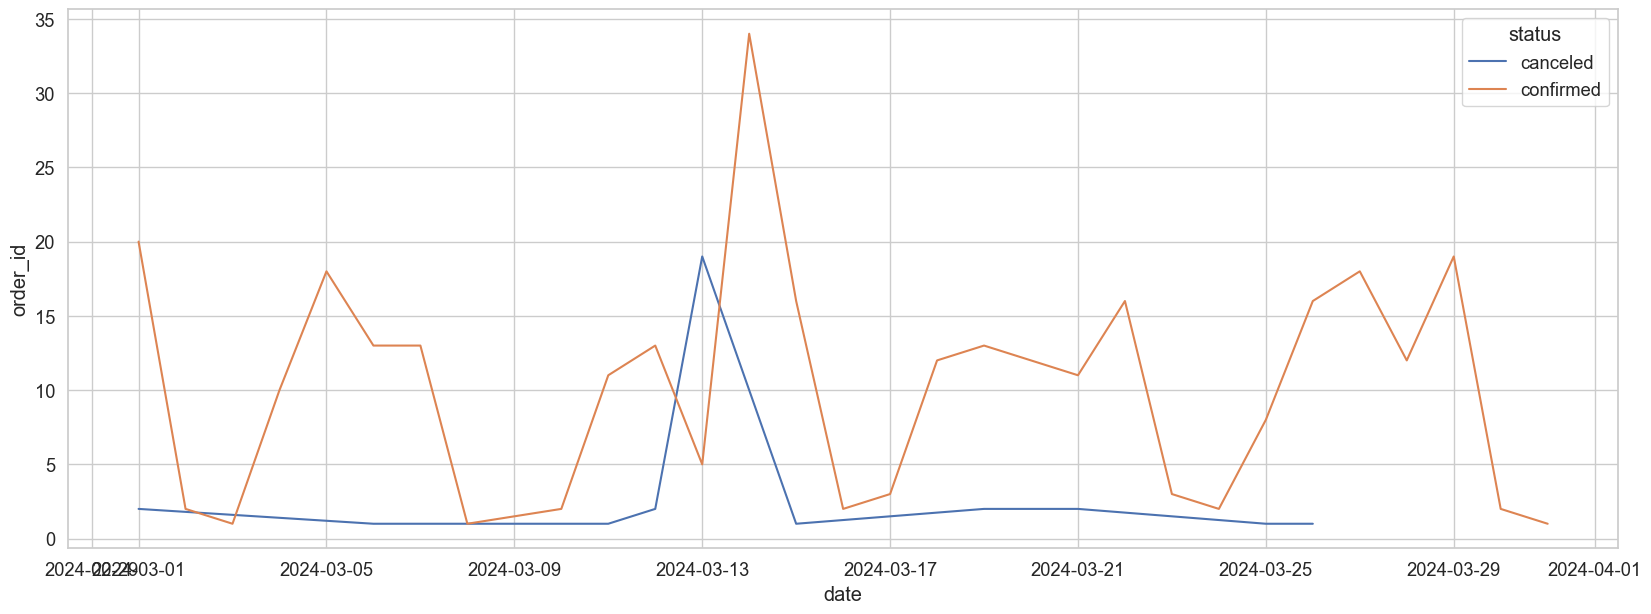

In [26]:
plt.figure(figsize=(20,7))
sns.lineplot(total_orders_by_status, x='date', y='order_id', hue='status')

Два дня отдельно

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Отберите все отмененные заказы 13 марта и для каждого заказа агрегируйте данные: посчитайте количество уникальных товаров в нем, сумму единиц всех товаров, а также возьмите менеджера и клиента (примените к соответствующим колонкам функции `max`).
      
2) Отберите все подтвержденные заказы 14 марта и для каждого заказа агрегируйте данные: посчитайте количество уникальных товаров в нем, сумму единиц всех товаров, а также возьмите менеджера и клиента (примените к соответствующим колонкам функции `max`).
      
3) Объедините эти датафреймы с заказами по совпадающим характеристикам: имя менеджера, id клиента, число уникальных товаров в заказе и общее число товаров в штуках. Так у вас получатся те заказы, которые отменили в первый день и оформили заново на следующий.
      
4) Посчитайте число строк в датафрейме с заказами, которые отменили в первый день и оформили заново на следующий. Разделите это число на число строк в датафрейме с подтвержденными заказами 14 марта. Так вы узнаете долю заказов, которые повторяют вчерашние.
      
</p>
</details>

In [ ]:
# 13 марта

In [27]:
day_13 = orders_status.loc[orders_status.date.dt.day == 13]
day_13.status.value_counts()

status
canceled     263
confirmed     76
Name: count, dtype: int64

In [ ]:
# 14 марта

In [28]:
day_14 = orders_status.loc[orders_status.date.dt.day == 14]
day_14.status.value_counts()

status
confirmed    437
Name: count, dtype: int64

In [29]:
day_13.merge(day_14, how='inner', on=['product_id', 'quantity', 'manager', 'client_id']).shape

(223, 10)

### ключевые метрики, посмотрим на их динамику и составим небольшой отчет

В данных цена единицы товара указана в долларах США, потому что закупаем их в долларах, но продаем товары за российские рубли (по тому курсу, который установил Центробанк на дату продажи), а значит и метрики требуется посчитать в рублях.

In [30]:
dollars = []
with open('usd_rate.txt') as f:
    for i in f.readlines():
        dollars.append(i.strip().split(','))
        
col = ['date', 'value', 'currency']

In [31]:
dollars_df = pd.DataFrame(columns=col, data=dollars) 

In [32]:
dollars_df.value = dollars_df.value.astype(float)

In [33]:
dollars_df.date = pd.to_datetime(dollars_df.date)

In [34]:
dollars_df.value.mean().round(2)
dollars_df.head()

,date,value,currency
0,2024-03-01,90.8423,Доллар США
1,2024-03-02,91.3336,Доллар США
2,2024-03-03,91.3336,Доллар США
3,2024-03-04,91.3336,Доллар США
4,2024-03-05,91.3534,Доллар США


### Работа с ключевыми метриками начните с подсчета общей выручки

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Присоедините к датафрейму `orders_status` датафрейм `df_products`, указав, что ключом в левом датафрейме будет являться колонка `product_id` (параметр `left_on`), а в правом — колонка `id` (параметр `right_on`). Новый датафрейм сохраните в `df_full`.
      
2) К датафрейму `df_full` добавьте информацию о курсе доллара на каждую дату, присоединив датафрейм `df_currency` по общей колонке с датой.
      
3) Создайте колонку `price_rub` с ценами в рублях. Для этого умножьте значения в колонке `price` с ценами на значения в колонке `currency_rate` с курсом валюты.
      
4) Создайте колонку `revenue` с выручкой, умножив колонку со стоимостью единицы товара в рублях на колонку с количеством товара.
      
5) Отберите только записи с подтвержденными заказами и сохраните результат в датафрейм `df_confirmed`, он вам ещё пригодится.
      
6) Суммируйте значения в колонке `revenue` и округлите результат до двух знаков после точки.
      
</p>
</details>

In [35]:
df_full = orders_status[orders_status.status=='confirmed'].merge(df_products[['id', 'price']], left_on='product_id', right_on='id')

In [36]:
df_full = df_full.merge(dollars_df[['date', 'value']], on='date').rename(columns={'value': 'curr_dlr'})

In [37]:
df_full['price_rub'] = df_full.price * df_full.quantity * df_full.curr_dlr

In [38]:
total_revenue = df_full.price_rub.sum().round(2)

#### средний чек в этом месяце (в рублях)

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Посчитайте число уникальных подтвержденных заказов.

2) Разделите сумму выручки, посчитанную на прошлом шаге (без округления), на это число.

3) Результат округлите до двух знаков после точки.  
      
</p>
</details>

In [39]:
abg_total_revenue = (total_revenue / df_full.order_id.nunique()).round(2)
abg_total_revenue

np.float64(6596219.49)

In [99]:
df_full

,order_id,product_id,quantity,manager,date,client_id,status,id,price,curr_$,curr_dlr,price_rub
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed,72,158.91,90.7493,90.7493,4.326291e+05
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed,509,43.95,90.7493,90.7493,1.595373e+05
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed,555,159.13,90.7493,90.7493,3.754643e+05
3,ABID-18767701,557,30,Маргарита Камертонова,2024-03-11,44,confirmed,557,308.70,90.7493,90.7493,8.404293e+05
4,ABID-18767701,569,28,Маргарита Камертонова,2024-03-11,44,confirmed,569,178.47,90.7493,90.7493,4.534888e+05
...,...,...,...,...,...,...,...,...,...,...,...,...
4078,ZVTW-19610380,1171,28,Ксения Балалайкина,2024-03-22,44,confirmed,1171,405.50,91.9499,91.9499,1.043999e+06
4079,ZVTW-19610380,1308,4,Ксения Балалайкина,2024-03-22,44,confirmed,1308,59.71,91.9499,91.9499,2.196131e+04
4080,ZVTW-19610380,1476,4,Ксения Балалайкина,2024-03-22,44,confirmed,1476,98.17,91.9499,91.9499,3.610689e+04
4081,ZVTW-19610380,1517,11,Ксения Балалайкина,2024-03-22,44,confirmed,1517,870.99,91.9499,91.9499,8.809619e+05


In [40]:
metrics = df_full.groupby(['date'], as_index=False) \
    .agg({'price_rub' :'sum',
         'order_id': 'nunique'})
metrics['avg_price'] = (metrics['price_rub'] / metrics['order_id']).round(2)

In [41]:
metrics.sort_values('date')

,date,price_rub,order_id,avg_price
0,2024-03-01,1.554118e+08,20,7770587.80
1,2024-03-02,1.197167e+07,2,5985834.26
2,2024-03-03,2.548418e+06,1,2548418.42
3,2024-03-04,6.404993e+07,10,6404992.56
4,2024-03-05,8.952724e+07,18,4973735.46
5,2024-03-06,1.107687e+08,13,8520669.46
6,2024-03-07,9.102331e+07,13,7001792.83
7,2024-03-08,1.609147e+06,1,1609146.62
8,2024-03-10,8.929309e+06,2,4464654.57
9,2024-03-11,8.910847e+07,11,8100769.59


In [42]:
df_full.head(3)

,order_id,product_id,quantity,manager,date,client_id,status,id,price,curr_dlr,price_rub
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed,72,158.91,90.7493,432629.137890
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed,509,43.95,90.7493,159537.269400
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed,555,159.13,90.7493,375464.338834


### Проанализируем интерес клиентов к брендам

#### Какие бренды востребованы среди клиентов

In [43]:
df_full = df_full.merge(df_products[['id', 'name']], on='id')

In [44]:
df_full['brand'] = df_full.name.apply(lambda x: x.split(',')[0])

In [45]:
df_full.brand.nunique()

121

### Какую выручку принес каждый бренд и в скольких подтвержденных заказах были товары этого бренда

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Отберите в датафрейме `df_full` только подтвержденные заказы.

2) Сгруппируйте данные по брендам и посчитайте выручку и количество уникальных заказов.

3) Отсортируйте агрегированные данные по убыванию выручки и посмотрите бренд в верхней строчке.

4) Дополнительно: отсортируйте агрегированные данные по убыванию количество заказов и посмотрите бренд в верхней строчке.

</p>
</details>

In [46]:
df_full[df_full.status=='confirmed'].groupby('brand') \
    .agg({'price_rub': 'sum'}) \
    .sort_values('price_rub', ascending=False)

df_full[df_full.status=='confirmed'].brand.value_counts()

brand
JBL            592
Heco           435
Yamaha         387
Klipsch        321
Magnat         206
              ... 
AudioSource      1
JVC              1
Technics         1
Microsoft        1
Bravo Audio      1
Name: count, Length: 121, dtype: int64

#### Какие бренды редко попадают в заказы, хотя товаров таких брендов на самом деле много

In [56]:
import numpy as np

In [48]:
df_confirmed = df_full[df_full.status=='confirmed']

In [60]:
products_in_orders = df_confirmed.product_id.unique()

In [61]:
df_products['is_in_orders'] = np.where(df_products.id.isin(products_in_orders), 'yes', 'no')

In [68]:
df_products.is_in_orders.value_counts()

is_in_orders
yes    1180
no      497
Name: count, dtype: int64

### у каких брендов доля ни разу не заказанных товаров была больше половины от всех продаваемых товаров этого бренда

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
       
1) В датафрейме `df_products` создайте новую колонку `brand`, в которую поместите только названия брендов. Для этого разделите значения в колонке `name` и возьмите первое из них (сначала идет бренд и через запятую модель товара).
      
2) Сгруппируйте данные по бренду и колонке, в которой указано, есть товар в заказах, и посчитайте число уникальных товаров. Колонку с числом товаров можете переименовать в `products`.
      
3) Разверните сгруппированные данные так, чтобы получилась сводная таблица в которой в индексе названия брендов, в колонках - есть товар в заказах или нет (`yes` и `no`), в значениях - количество товаров.
      
4) Заполните пропуски нулями.
      
5) Сбросьте индекс, чтобы названия брендов стали колонкой.
      
6) Посчитайте общее число товаров для каждого бренда, сложив значения в колонках `yes` и `no`.
      
7) Для каждого бренда посчитайте долю ни разу не заказанных товаров от всех продаваемых товаров этого бренда.
      
8) Отберите только те бренды, где общее число товаров больше 15 и доля ни разу не заказанных товаров больше половины (0.5).
      
</p>
</details>

In [79]:
df_products['brand'] = df_products.name.apply(lambda x: x.split(',')[0])

In [92]:
df = df_products.groupby(['brand', 'is_in_orders'], as_index=False) \
    .agg({'id': 'count'}) \
    .pivot(index='brand', columns='is_in_orders', values='id') \
    .fillna(0)


In [95]:
df['total_products'] = df.no + df.yes

In [99]:
df['without_orders'] = (df.no / df.total_products).round(2)

In [102]:
df[(df.total_products >= 15) & (df.without_orders > 0.5)]

is_in_orders,no,yes,total_products,without_orders
brand,,,,
Dali,49.0,18.0,67.0,0.73
KEF,54.0,28.0,82.0,0.66
Marantz,19.0,3.0,22.0,0.86
Pioneer,70.0,33.0,103.0,0.68


### Составим отчет по продажам менеджеров

<Axes: xlabel='percent_orders', ylabel='manager'>

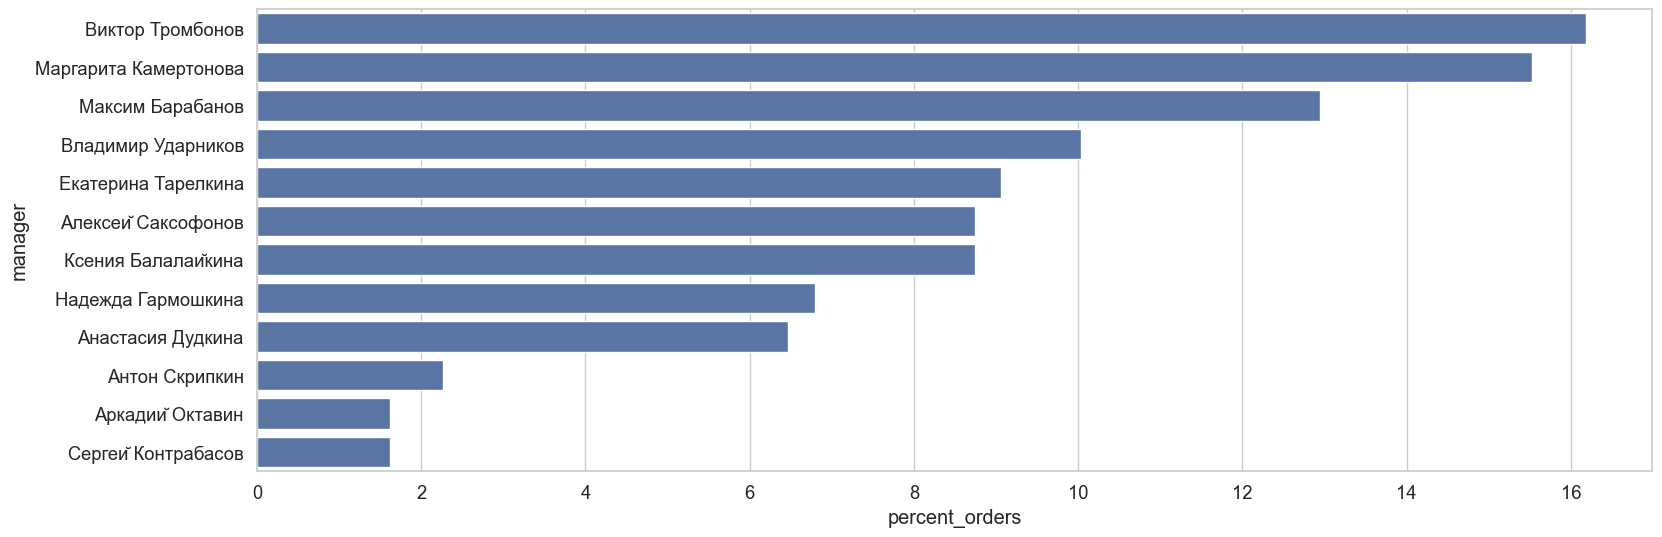

In [143]:
sns.barplot(data=revenue_by_manager.sort_values('percent_orders', ascending=False),
           x='percent_orders', y='manager'
            )

<Axes: xlabel='percent_revenue', ylabel='manager'>

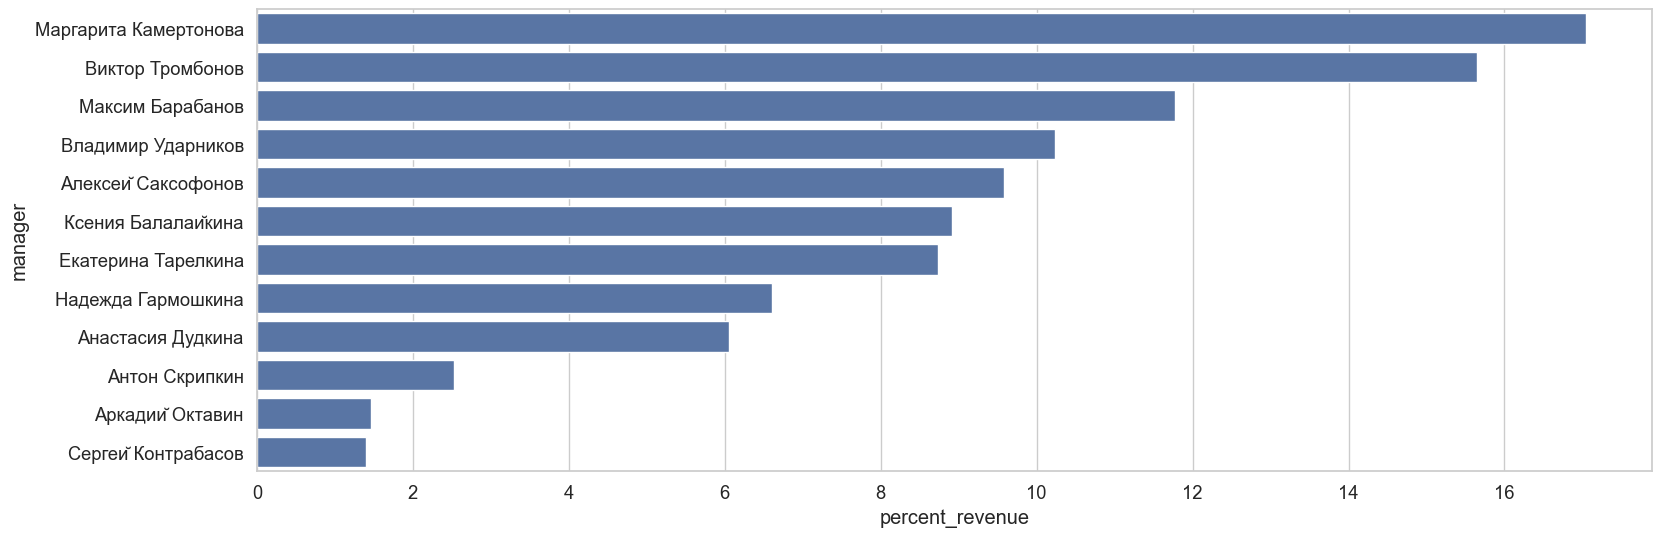

In [144]:
sns.barplot(data=revenue_by_manager.sort_values('percent_revenue', ascending=False),
           x='percent_revenue', y='manager'
            )

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
       
1) Сгруппируйте данные с подтвержденными заказами из датафрейма `df_confirmed` по менеджерам и посчитайте для каждого сумму выручки и количество заказов. Получившуюся колонку с числом заказов можете переименовать в `orders`.
      
2) Отсортируйте записи по убыванию выручки.
      
3) Посчитайте процент выручки, приходящейся на каждого менеджера: разделите его выручку на суммарную выручку всех менеджеров и умножьте результат на 100. Округлите до двух знаков после точки.
      
4) Посчитайте процент заказов, приходящихся на каждого менеджера: разделите его число заказов на суммарное число заказов всех менеджеров и умножьте результат на 100. Округлите до двух знаков после точки.   
      
5) Постройте два барплота (столбиковые диаграммы): со значениями % выручки и % заказов у каждого менеджера.
      
</p>
</details>

In [110]:
revenue_by_manager = df_full.groupby('manager', as_index=False) \
    .agg({'price_rub': 'sum',
         'order_id': 'nunique'
         }) \
    .rename(columns={'price_rub': 'revenue', 'order_id': 'cnt_orders'})

In [115]:
revenue_by_manager = revenue_by_manager.assign(total_revenue = revenue_by_manager.revenue.sum(),
                         total_orders = revenue_by_manager.cnt_orders.sum()
                         )

In [132]:
revenue_by_manager = revenue_by_manager.assign(percent_revenue = round(revenue_by_manager.revenue / revenue_by_manager.total_reven * 100, 2),
                         percent_orders = round(revenue_by_manager.cnt_orders / revenue_by_manager.total_orders * 100, 2)
                         )

## Итоги

Проанализировали продажи музыкальных товаров: собрали данные, посчитали ключевые метрики в динамике; определили дни, которые выбиваются из общей картины, и выяснили причину этого; наш
ли наиболее прибыльные бренды и те, которые зря занимают место на виртуальной «полке». 